# Lesson 4: LLM Node

## *The Model Becomes the Decision-Maker*

---

### Why This Matters

Until now, every decision in our graphs was made by code we wrote: compare a number, check a list. That works when the rules are clear and finite.

But some decisions cannot be reduced to rules. A customer writes "I keep getting billed for something I cancelled." Which department handles that? You would need thousands of if-statements to cover every way a person might phrase a complaint. Instead, you hand the task to something that already understands language: a Large Language Model.

---

### The Mental Model

> **Think of a call center operator.**
>
> When a customer calls, an automated phone menu might say: "Press 1 for billing, Press 2 for technical support." That forces the customer to self-classify - and they often get it wrong.
>
> A better approach: a human operator listens to the customer describe their problem in their own words, understands what they actually need, and transfers them to the right department.
>
> That operator is your LLM node. It listens (reads the message), understands (processes language), and routes (writes the department to State). The customer never has to "Press 1" - they just talk naturally.

---

### What We Will Build

Exactly that call center operator - as a LangGraph node. The LLM reads customer messages and routes them to the correct department.

| Input | LLM Decision | Routed To |
|:---|:---|:---|
| "Why was I charged twice?" | billing | Billing handler |
| "App keeps crashing" | technical | Tech support handler |
| "What are your hours?" | general | General handler |

```
START -> llm_classifier -> [LLM decides department]
                              |
               +--------------+--------------+
               |              |              |
        billing_handler  technical_handler  general_handler
               |              |              |
              END            END            END
```

---

## Step 1: Setup

First time our graph talks to an actual LLM. We need `langchain-openai`.

In [75]:
!pip install -q -U langgraph langchain-openai


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\sk72\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [76]:
import os

try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
except ImportError:
    from dotenv import load_dotenv
    load_dotenv(override=True)

In [78]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI

---

## Step 2: Define State

| Field | Purpose |
|:---|:---|
| `messages` | The conversation history |
| `department` | Where the LLM decides the question belongs |

> The LLM will *write* to the department field. Previous lessons used if-statements to do this. Now the model figures it out from context.

In [79]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    department: str

---

## Step 3: Create the LLM

We instantiate a ChatOpenAI model. This is the "trained professional" from our mental model - ready to receive instructions and respond with judgment.

In [80]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

---

## Step 4: Define the LLM Node

The `llm_classifier` node does three things:
1. Takes the user message from State
2. Asks the LLM to classify it (with a constrained system prompt)
3. Writes the classification back to State

> **Key Technique**: We give the LLM a system prompt that constrains output to exactly one of three words. This is how you make LLM output reliable enough for routing - give it a narrow, well-defined task with explicit options.

In [81]:
def llm_classifier(state: State):
    """Uses the LLM to classify the customer question into a department."""
    last_message = state["messages"][-1]
    user_text = last_message.content if hasattr(last_message, 'content') else str(last_message[1])

    # The system prompt constrains the LLM to return exactly one word
    classification_prompt = [
        ("system", (
            "You are a customer service router. "
            "Classify the following customer message into exactly one category. "
            "Reply with ONLY one word: billing, technical, or general. "
            "No punctuation, no explanation."
        )),
        ("human", user_text)
    ]

    response = llm.invoke(classification_prompt)
    department = response.content.strip().lower()

    # Safety fallback in case LLM returns unexpected output
    if department not in ["billing", "technical", "general"]:
        department = "general"

    return {"department": department}

---

## Step 5: Define the Handler Nodes

Each department has a specialized handler. In a real system, each could be its own LLM with domain-specific prompts, or a connection to a different backend.

In [82]:
def billing_handler(state: State):
    """Handles billing questions."""
    return {"messages": [("ai", "[Billing Dept] I can help with your billing question. Let me look up your account details.")]}


def technical_handler(state: State):
    """Handles technical support questions."""
    return {"messages": [("ai", "[Tech Support] I can help troubleshoot that issue. Let me walk you through some steps.")]}


def general_handler(state: State):
    """Handles general inquiries."""
    return {"messages": [("ai", "[General] Thanks for reaching out! Let me help you with that.")]}

---

## Step 6: Routing Function and Graph Assembly

Same structural pattern as Lesson 2, but now the `department` field was filled by the LLM, not by a keyword check.

In [83]:
def route_to_department(state: State) -> str:
    """Routes based on LLM classification."""
    return f"{state['department']}_handler"


workflow = StateGraph(State)

# Register nodes
workflow.add_node("llm_classifier", llm_classifier)
workflow.add_node("billing_handler", billing_handler)
workflow.add_node("technical_handler", technical_handler)
workflow.add_node("general_handler", general_handler)

# Edges
workflow.add_edge(START, "llm_classifier")

# Path map explicitly lists all possible destinations for the renderer
workflow.add_conditional_edges(
    "llm_classifier",
    route_to_department,
    {"billing_handler": "billing_handler", "technical_handler": "technical_handler", "general_handler": "general_handler"}
)

workflow.add_edge("billing_handler", END)
workflow.add_edge("technical_handler", END)
workflow.add_edge("general_handler", END)

app = workflow.compile()

---

## Step 7: Test with Different Questions

Watch how the LLM understands context and nuance. "Why was I charged twice" does not contain the word "billing", yet it gets routed correctly because the LLM understands *intent*.

In [84]:
test_messages = [
    "Why was I charged twice this month?",
    "My app keeps crashing when I open settings",
    "What are your business hours?"
]

for msg in test_messages:
    result = app.invoke({"messages": [("human", msg)], "department": ""})
    print(f"Question: {msg}")
    print(f"Routed to: {result['department']}")
    print(f"Response: {result['messages'][-1].content}")
    print("---")

Question: Why was I charged twice this month?
Routed to: billing
Response: [Billing Dept] I can help with your billing question. Let me look up your account details.
---
Question: My app keeps crashing when I open settings
Routed to: technical
Response: [Tech Support] I can help troubleshoot that issue. Let me walk you through some steps.
---
Question: What are your business hours?
Routed to: general
Response: [General] Thanks for reaching out! Let me help you with that.
---


---

## Step 8: Visualize the Graph

The LLM classifier sits at the center, fanning out to three specialized handlers via conditional edges.

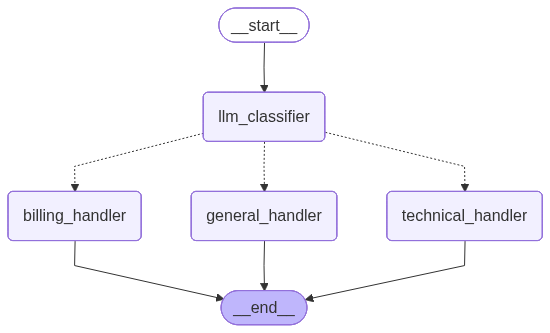

In [85]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

---

## Summary

### What Changed from Lesson 2

| Lesson 2 (Rules) | Lesson 4 (LLM) |
|:---|:---|
| `if amount < 100` | LLM reads and understands intent |
| Brittle, breaks on edge cases | Handles nuance and ambiguity |
| Zero latency, zero cost | API call with latency and cost |
| Predictable, testable | Probabilistic, needs fallbacks |

---

### Key Takeaways

> 1. An LLM node is just a regular node that calls a model
> 2. Constrain LLM output with system prompts for reliable routing
> 3. Always add a fallback for unexpected LLM output
> 4. The graph structure stays clean - the intelligence lives in the nodes

---

**Next Lesson**: The agent can now *think*, but it cannot *do* anything in the real world. Lesson 5 gives it hands with tools.